<a href="https://colab.research.google.com/github/JenniferShearer/ENDG-511-Project-Repo/blob/main/project_jenny.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import datasets

In [ ]:
#upload kaggle.json
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ollioctopus","key":"2298f6afa30a662432bb6061be671df4"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!pip install kagglehub

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ollioctopus/asl-dataset")

print("Path to dataset files:", path)

100%|██████████| 741M/741M [00:13<00:00, 57.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ollioctopus/asl-dataset/versions/4


In [1]:
import subprocess
import sys
from pathlib import Path
import json
from dataclasses import dataclass
import math
from typing import Optional
from tqdm.auto import tqdm
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
import h5py
from timm.utils import accuracy
from timm.layers import trunc_normal_
import matplotlib.pyplot as plt
import os
import random
from PIL import Image
from glob import glob
from sklearn.model_selection import train_test_split
import shutil
import pandas as pd
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, Model
import tensorflow as tf
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import keras


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataset_path = path + "/data/data"
output_path = path + "/dataset_split"

valid_ext = (".jpg", ".jpeg", ".png")

image_paths = []
labels = []

# collect full dataset and labels
for label in os.listdir(dataset_path):
    label_path = os.path.join(dataset_path, label)

    if not os.path.isdir(label_path):
        continue

    for f in os.listdir(label_path):
        if f.lower().endswith(valid_ext):
            full_path = os.path.join(label_path, f)
            image_paths.append(full_path)
            labels.append(label)

# Train/Test split -> random 42 to reporduce it
train_paths, test_paths, train_labels, test_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

# make function to copy paths into folders
def copy_to_split(paths, labels, split_name):
    for src_path, label in zip(paths, labels):
        dest_dir = os.path.join(output_path, split_name, label)
        os.makedirs(dest_dir, exist_ok=True)

        filename = os.path.basename(src_path)
        dest_path = os.path.join(dest_dir, filename)

        shutil.copy2(src_path, dest_path)

# copy into class folders
copy_to_split(train_paths, train_labels, "train")
copy_to_split(test_paths, test_labels, "test")

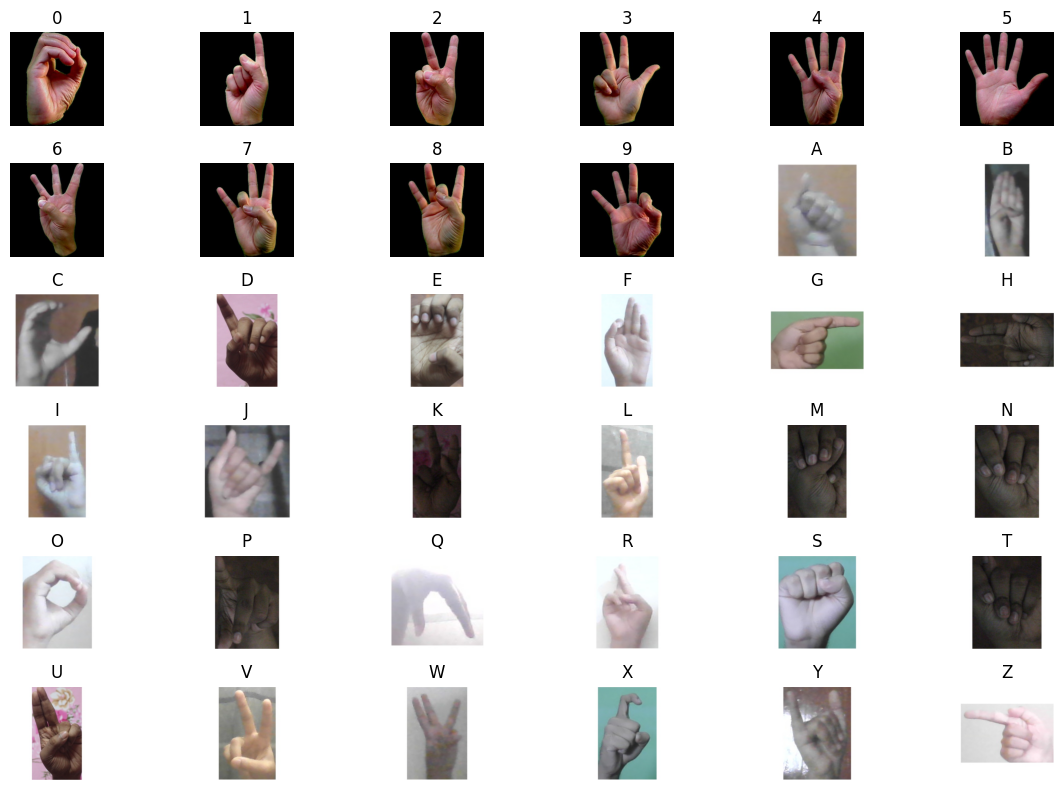

In [ ]:
train_path = path + "/dataset_split/train"  # train path
labels = sorted(os.listdir(train_path))      # labels from folder names

plt.figure(figsize=(12, 8))

for i, label in enumerate(labels):
    label_path = os.path.join(train_path, label)

    if not os.path.isdir(label_path):
        continue

    # move images to class folder
    valid_ext = (".jpg", ".jpeg", ".png")
    images = [
        f for f in os.listdir(label_path)
        if f.lower().endswith(valid_ext) and os.path.isfile(os.path.join(label_path, f))
    ]

    if len(images) == 0:
        continue

    # pick one random image per class
    img_name = random.choice(images)
    img_path = os.path.join(label_path, img_name)
    img = Image.open(img_path)

    plt.subplot(6, 6, i + 1)
    plt.imshow(img)
    plt.title(label.upper())
    plt.axis("off")

plt.tight_layout()
plt.show()

load the base of MobileNetV2

In [ ]:
BaseModel = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3))

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Find what layers we should exit from:

In [ ]:
for i, layer in enumerate(BaseModel.layers):
  print(i, layer.name)

0 input_layer
1 Conv1
2 bn_Conv1
3 Conv1_relu
4 expanded_conv_depthwise
5 expanded_conv_depthwise_BN
6 expanded_conv_depthwise_relu
7 expanded_conv_project
8 expanded_conv_project_BN
9 block_1_expand
10 block_1_expand_BN
11 block_1_expand_relu
12 block_1_pad
13 block_1_depthwise
14 block_1_depthwise_BN
15 block_1_depthwise_relu
16 block_1_project
17 block_1_project_BN
18 block_2_expand
19 block_2_expand_BN
20 block_2_expand_relu
21 block_2_depthwise
22 block_2_depthwise_BN
23 block_2_depthwise_relu
24 block_2_project
25 block_2_project_BN
26 block_2_add
27 block_3_expand
28 block_3_expand_BN
29 block_3_expand_relu
30 block_3_pad
31 block_3_depthwise
32 block_3_depthwise_BN
33 block_3_depthwise_relu
34 block_3_project
35 block_3_project_BN
36 block_4_expand
37 block_4_expand_BN
38 block_4_expand_relu
39 block_4_depthwise
40 block_4_depthwise_BN
41 block_4_depthwise_relu
42 block_4_project
43 block_4_project_BN
44 block_4_add
45 block_5_expand
46 block_5_expand_BN
47 block_5_expand_relu


The expabded relu is where we want to make the early exits, before it is projected

In [ ]:
Exit1 = BaseModel.get_layer("block_3_expand_relu").output
Exit2 = BaseModel.get_layer("block_12_expand_relu").output

def ExitHead(x, NumClasses):
  x = layers.GlobalAveragePooling2D()(x)
  x = layers.Dense(128, activation='relu')(x)
  return layers.Dense(NumClasses, activation='softmax')(x)

Exit1Output = ExitHead(Exit1, 10)
Exit2Output = ExitHead(Exit2, 10)


x = BaseModel.output
x = layers.GlobalAveragePooling2D()(x)
FinalOutput = layers.Dense(10, activation='softmax')(x)

NewModel = Model(inputs=BaseModel.input,
                 outputs=[Exit1Output, Exit2Output, FinalOutput])


In [ ]:
num_classes = len(labels)
print(f"{num_classes} classes for training.")

# redefine train_ds and test_ds using
# Set label_mode='categorical' for one-hot encoding as categorical_crossentropy is used
train_ds = tf.keras.utils.image_dataset_from_directory(
    output_path + "/train",
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical' # Ensures labels are one-hot encoded
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    output_path + "/test",
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical' # Ensures labels are one-hot encoded
)


train_ds = train_ds.map(lambda x, y: (x, (y, y, y))) #makes a training map that fits the early exit size
test_ds = test_ds.map(lambda x, y: (x, (y, y, y)))

for images, labels_one_hot in test_ds.take(1):
    break

36 classes for training.
Found 35260 files belonging to 36 classes.
Found 8815 files belonging to 36 classes.


In [ ]:

# Redefine the ExitHead function and the model with the correct number of classes
Exit1 = BaseModel.get_layer("block_3_expand_relu").output
Exit2 = BaseModel.get_layer("block_12_expand_relu").output

def ExitHead(x, num_classes_arg):
  x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
  x = layers.BatchNormalization()(x)
  x = layers.GlobalAveragePooling2D()(x)
  x = layers.Dense(128, activation='relu')(x)
  x = layers.Dropout(0.5)(x)
  return layers.Dense(num_classes_arg, activation='softmax')(x)

Exit1Output = ExitHead(Exit1, num_classes)
Exit2Output = ExitHead(Exit2, num_classes)

x = BaseModel.output
x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
FinalOutput = layers.Dense(num_classes, activation='softmax')(x)

NewModel = Model(inputs=BaseModel.input,
                 outputs=[Exit1Output, Exit2Output, FinalOutput])

# Compile the model
NewModel.compile(
    optimizer='adam',
    loss=['categorical_crossentropy'] * 3,
    metrics=[tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top_3_acc')] * 3) # Fixed: metrics should be a list of 3 for 3 outputs

# Fit the model
print("\nStarting model training...")
NewModel.fit(
    train_ds,
    validation_data = test_ds,
    epochs = 10,
)



Starting model training...
Epoch 1/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 253s 177ms/step - dense_18_loss: 1.7159 - dense_18_top_3_acc: 0.8982 - dense_20_loss: 0.2675 - dense_20_top_3_acc: 0.8982 - dense_22_loss: 0.2014 - dense_22_top_3_acc: 0.8982 - loss: 2.1849 - val_dense_18_loss: 8.0186 - val_dense_18_top_3_acc: 0.5168 - val_dense_20_loss: 5.5522 - val_dense_20_top_3_acc: 0.5168 - val_dense_22_loss: 3.8112 - val_dense_22_top_3_acc: 0.5168 - val_loss: 17.3893
Epoch 2/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 157s 142ms/step - dense_18_loss: 1.1015 - dense_18_top_3_acc: 0.9560 - dense_20_loss: 0.0909 - dense_20_top_3_acc: 0.9560 - dense_22_loss: 0.0998 - dense_22_top_3_acc: 0.9560 - loss: 1.2922 - val_dense_18_loss: 9.8600 - val_dense_18_top_3_acc: 0.7021 - val_dense_20_loss: 1.2393 - val_dense_20_top_3_acc: 0.7021 - val_dense_22_loss: 0.8532 - val_dense_22_top_3_acc: 0.7021 - val_loss: 11.9444
Epoch 3/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 159s 144ms/step - dense_18_loss: 0.8824 - dense_18_top_3_acc

In [ ]:
#run if you want to use newely trained model
LoadedModel = NewModel

In [ ]:
results = LoadedModel.evaluate(test_ds, verbose=0)
metric_names = LoadedModel.metrics_names

# zip ensures matching length
df = pd.DataFrame(list(zip(metric_names, results)),
                  columns=["Metric", "Value"])

print(df.to_string(index=False))

         Metric    Value
           loss 4.285604
compile_metrics 3.719838
  dense_18_loss 0.474183
  dense_20_loss 0.092333
  dense_22_loss 0.879977


# Shows top 3 predictions and compares with actual

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf

#raw data
prediction_all = LoadedModel.predict(test_ds, verbose=0)
prediction_output = prediction_all[2]

top_3_indices = np.argsort(prediction_output, axis=1)[:, -3:][:, ::-1]

#creates a DataFrame to store results
df = pd.DataFrame(top_3_indices, columns=['Top1', 'Top2', 'Top3'])

#collects actual values
actual_values_list = []
for _, y_batch in test_ds:
    actual_values_list.extend(tf.argmax(y_batch[0], axis=1).numpy())
actual_values = np.array(actual_values_list)

df['Actual_Value'] = actual_values

# Shows
df['In_Top_3'] = df.apply(lambda row: row['Actual_Value'] in row[['Top1', 'Top2', 'Top3']].values, axis=1)

# display
df.to_csv('model_k_results.csv', index=False)

print(df.head())

   Top_1  Top_2  Top_3  Actual_Value  In_Top_3
0     33     14     27            11     False
1     22     23     19            19      True
2     18     19     13            33     False
3     16     10     20            27     False
4     35     16     34            26     False


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


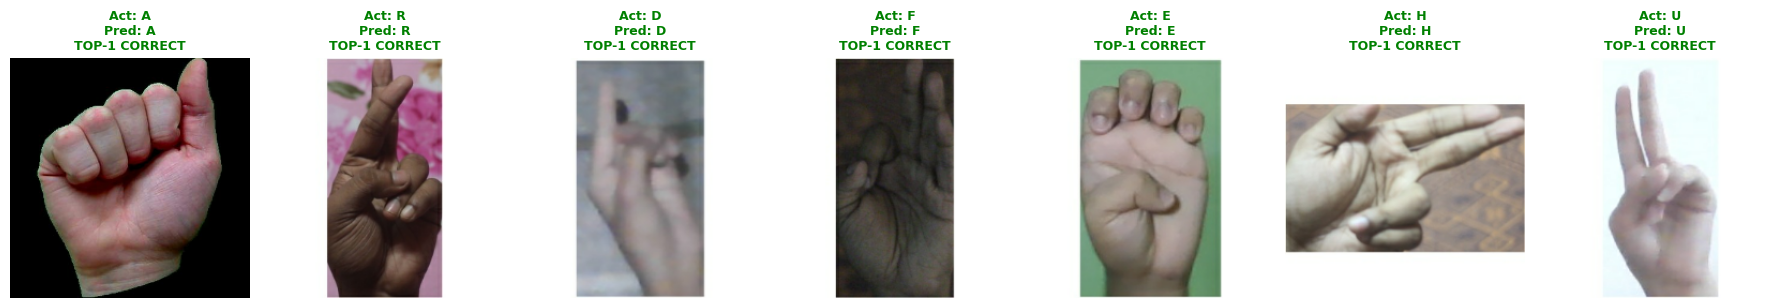

In [ ]:

num_to_show = 7 #number of images to display
subset_images_list = []
subset_labels_list = []

for i, (image, label_tuple) in enumerate(test_ds.unbatch().take(num_to_show)):
    subset_images_list.append(image.numpy())
    subset_labels_list.append(tf.argmax(label_tuple[0]).numpy())

subset_images = np.array(subset_images_list)
subset_labels = np.array(subset_labels_list)


predictions_all = LoadedModel.predict(subset_images)
predictions_final = [2]



plt.figure(figsize=(18, 5))
for i in range(num_to_show):
    top_3_indices = np.argsort(predictions_final[i])[-3:][::-1]

    actual_label_index = subset_labels[i]
    top_1_label_index = top_3_indices[0]

    # colors for predictions
    if actual_label_index == top_1_label_index:
        color = 'green'
        status = "TOP-1 CORRECT"
    elif actual_label_index in top_3_indices:
        color = 'orange'
        status = "TOP-3 CORRECT"
    else:
        color = 'red'
        status = "INCORRECT"

    # display image
    plt.subplot(1, num_to_show, i + 1)
    plt.imshow(subset_images[i].astype('uint8'))
    plt.axis('off')
    actual_class_name = labels[actual_label_index]
    predicted_class_name = labels[top_1_label_index]

    plt.title(f"Act: {actual_class_name.upper()} Pred: {predicted_class_name.upper()}{status}", color=color)

plt.tight_layout()
plt.show()

In [ ]:

y_pred0_list = []
y_pred1_list = []
y_pred2_list = []
y_trues_list = []
j=0

for x_batch, y_batch in test_ds:
  j+=1
  preds = LoadedModel.predict(x_batch, verbose=0)
  preds0_classes = np.argmax(preds[0], axis=1)
  preds1_classes = np.argmax(preds[1], axis=1)
  preds2_classes = np.argmax(preds[2], axis=1)
  y_trues_list.extend(tf.argmax(y_batch[0], axis=1).numpy())
  y_pred0_list.extend(preds0_classes)
  y_pred1_list.extend(preds1_classes)
  y_pred2_list.extend(preds2_classes)
  if j==10: #change depending on how many points in matrix you want
    break

y_preds = [np.array(y_pred0_list), np.array(y_pred1_list), np.array(y_pred2_list)]
y_true = np.array(y_trues_list)


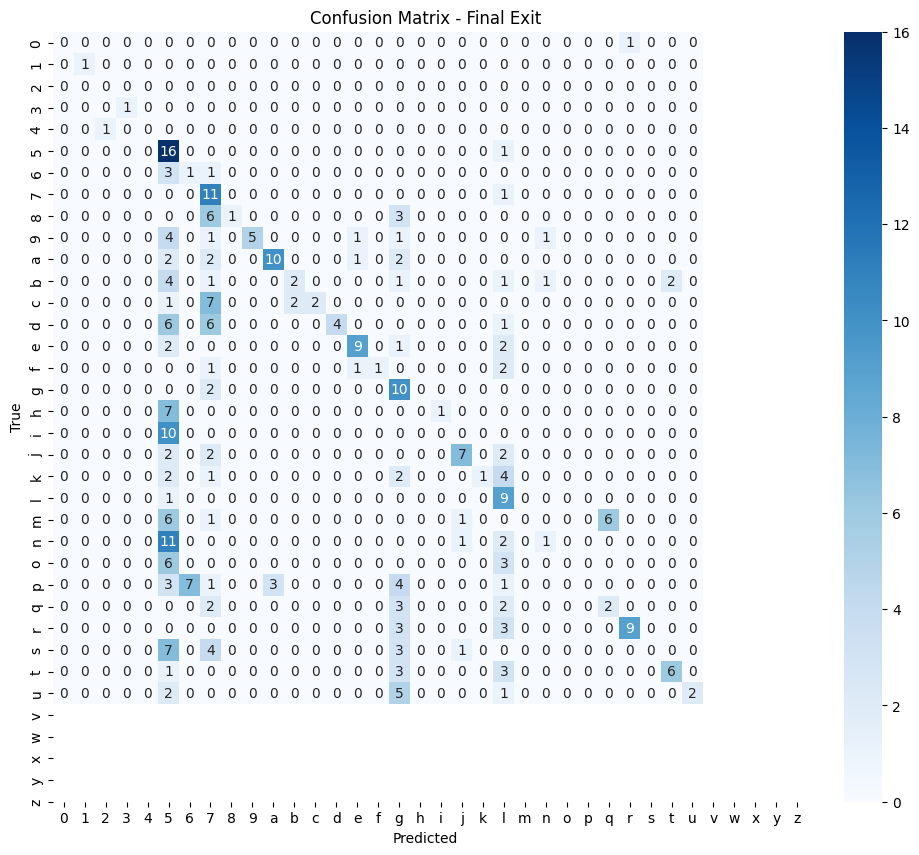

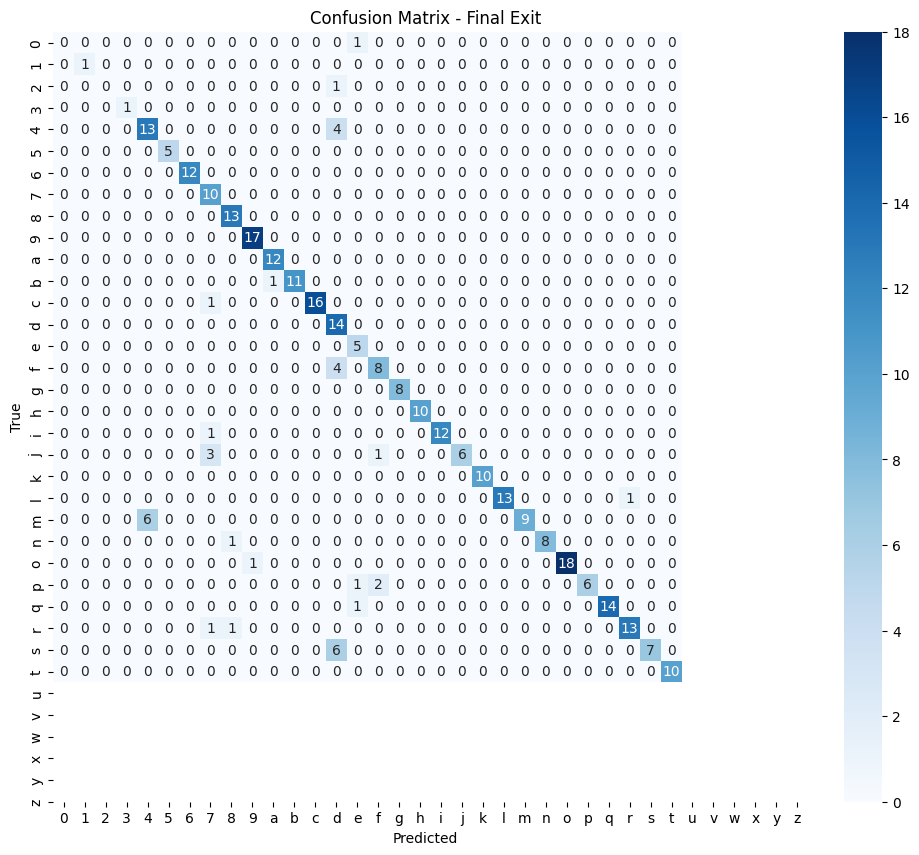

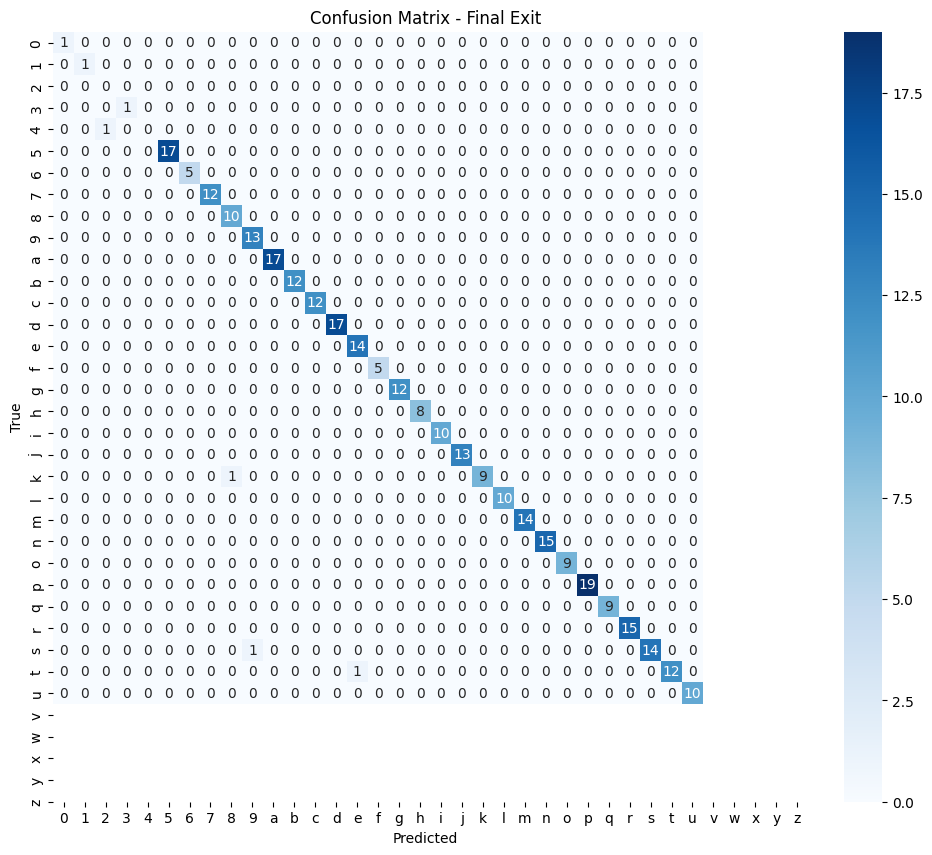

In [ ]:

for y_pred in y_preds:
  cm = confusion_matrix(y_true, y_pred)
  class_labels = sorted(os.listdir(output_path + "/train"))

  plt.figure(figsize=(12,10))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
              xticklabels=class_labels,
              yticklabels=class_labels)
  plt.xlabel("Predicted")
  plt.ylabel("True")
  plt.title("Confusion Matrix - Final Exit")
  plt.show()